# Qual é o melhor plano?

Você trabalha como analista para a empresa de telecomunicações Megaline. A empresa oferece aos clientes dois planos pré-pagos: Surf e Ultimate. O departamento comercial quer saber qual dos planos gera mais receita para ajustar o orçamento de publicidade.

Você vai realizar uma análise preliminar dos planos com base em uma pequena seleção de clientes. Você terá dados de 500 clientes da Megaline: que clientes são, de onde eles são, qual plano usam e o número de chamadas e mensagens realizadas em 2018. Seu trabalho é analisar o comportamento dos clientes e determinar qual plano pré-pago gera mais receita.

## Inicialização

O propósito deste projeto é usar as ferramentas do Python para entregar um resulado suscinto, que venha facilitar a vida do cliente na sua tomada de decisão: Decidir como irá direcionar os investimentos em marketing.

In [1]:
#1 Carregando todas as bibliotecas
import pandas as pd
from scipy import stats as st
import matplotlib.pyplot as plt
import numpy as np
from math import ceil
import seaborn as sns


In [2]:
#1.1 Set the maximum width for the output to be very large
pd.set_option('display.width', 1200)

# Ensure all columns are shown without being truncated with "..."
pd.set_option('display.max_columns', None)


## Carregue os dados

In [3]:
#2 Carregue os arquivos de dados em diferentes DataFrames

df_calls = pd.read_csv('megaline_calls.csv') # change the 'call_date' column to data_type

df_internet = pd.read_csv('megaline_internet.csv') # may change the 'session_date' to data_type

df_messages = pd.read_csv('megaline_messages.csv') # may change the 'message_data' to data_type

df_plans = pd.read_csv('megaline_plans.csv', sep = ',')

df_users = pd.read_csv('megaline_users.csv') # the column 'reg_date' has only 34 non-null values


## Prepare os dados

[Os dados deste projeto estão divididos em várias tabelas. Explore cada uma para obter uma compreensão inicial dos dados. Faça correções em cada tabela, se necessário.]

## Plans


In [4]:
#3 Imprima informações gerais/resumo sobre o DataFrame dos planos

print(df_plans.dtypes)
print()
display(df_plans.info())
print()
print(df_plans.describe())
print()
print(df_plans.columns)
print()
print(df_plans.shape)
print()


messages_included          int64
mb_per_month_included      int64
minutes_included           int64
usd_monthly_pay            int64
usd_per_gb                 int64
usd_per_message          float64
usd_per_minute           float64
plan_name                    str
dtype: object

<class 'pandas.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      str    
dtypes: float64(2), int64(5), str(1)
memory usage: 260.0 bytes


None


       messages_included  mb_per_month_included  minutes_included  usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute
count           2.000000               2.000000          2.000000         2.000000     2.00000         2.000000        2.000000
mean          525.000000           23040.000000       1750.000000        45.000000     8.50000         0.020000        0.020000
std           671.751442           10861.160159       1767.766953        35.355339     2.12132         0.014142        0.014142
min            50.000000           15360.000000        500.000000        20.000000     7.00000         0.010000        0.010000
25%           287.500000           19200.000000       1125.000000        32.500000     7.75000         0.015000        0.015000
50%           525.000000           23040.000000       1750.000000        45.000000     8.50000         0.020000        0.020000
75%           762.500000           26880.000000       2375.000000        57.500000     9.25000         

In [5]:
#4 Imprima uma amostra de dados dos planos

display(df_plans.head())


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


[Descreva o que você nota sobre as informações gerais e sobre a amostra de dados impressa acima. Existem problemas (tipos de dados inadequados, dados ausentes, etc.) que precisam de mais investigação e alterações? Como isso pode ser corrigido?]


As colunas 'usd_monthly_pay' e 'usd_per_gb' estão no formato int64 e precisam ser convertidas para o tipo float64 para que eu possa fazer cálculos futuros sem problemas.

A coluna 'mb_per_month_included' deve ser trocada por uma coluna que mostre os valores em gigabites, já que os dados são computados e cobrados em gb, conforme é mostrado na coluna 'usd_per_gb'


## Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [6]:
#5 replacing the datatypes
df_plans['usd_monthly_pay'] = df_plans['usd_monthly_pay'].astype('float64')

df_plans['usd_per_gb'] = df_plans['usd_per_gb'].astype('float64')


## Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [7]:
#6 creating a new column with gb instead of mb
df_plans['gb_per_month_included'] = df_plans['mb_per_month_included'] / 1024

#removing the unusefull column
df_plans = df_plans.drop(columns = ['mb_per_month_included'])

# rounding up the values
df_plans['gb_per_month_included'] = df_plans['gb_per_month_included'].apply(ceil)

display(df_plans)


,messages_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included
0,50,500,20.0,10.0,0.03,0.03,surf,15
1,1000,3000,70.0,7.0,0.01,0.01,ultimate,30


## Users

In [8]:
#7 Imprima informações gerais/resumo sobre o DataFrame dos usuários

print(df_users.dtypes)
print()
df_users.info()
print()
print(df_users.describe())
print()
print(df_users.columns)
print()
print(df_users.shape)
print()


user_id       int64
first_name      str
last_name       str
age           int64
city            str
reg_date        str
plan            str
churn_date      str
dtype: object

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   user_id     500 non-null    int64
 1   first_name  500 non-null    str  
 2   last_name   500 non-null    str  
 3   age         500 non-null    int64
 4   city        500 non-null    str  
 5   reg_date    500 non-null    str  
 6   plan        500 non-null    str  
 7   churn_date  34 non-null     str  
dtypes: int64(2), str(6)
memory usage: 31.4 KB

           user_id         age
count   500.000000  500.000000
mean   1249.500000   45.486000
std     144.481833   16.972269
min    1000.000000   18.000000
25%    1124.750000   30.000000
50%    1249.500000   46.000000
75%    1374.250000   61.000000
max    1499.000000   75.000000

Index(['user_i

In [9]:
#8 Imprima uma amostra de dados dos usuários

display(df_users.sample(5))


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
433,1433,Lyndon,Morrison,29,"Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA",2018-08-29,ultimate,NaN
320,1320,Bert,Wells,23,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-02-23,surf,NaN
247,1247,Marion,Singleton,75,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-04-12,ultimate,NaN
223,1223,Patience,Wilson,37,"Phoenix-Mesa-Chandler, AZ MSA",2018-07-05,surf,NaN
123,1123,Dierdre,Nash,66,"Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA",2018-04-19,surf,NaN


[Descreva o que você nota sobre as informações gerais e sobre a amostra de dados impressa acima. Existem problemas (tipos de dados inadequados, dados ausentes, etc.) que precisam de mais investigação e alterações? Como isso pode ser corrigido?]

As colunas ['reg_date'] e ['churn_date'] deveriam estar no formato datetype64. A coluna '[churn_date]' tem a maior parte dos valores como NaN.

### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [10]:
#9  Changing some columns to datetime64

df_users['reg_date'] = pd.to_datetime(df_users['reg_date'])

df_users['churn_date'] = pd.to_datetime(df_users['churn_date'])


### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [11]:
#9.1
last_date = df_users['churn_date'].max()

print(last_date)


2018-12-31 00:00:00


In [12]:
#10 Já que os valores ausentes da coluna ['churn_date'] se referem a clientes ativos, faremos a Pandas preencher os valores nulos com a última data registrada na tabela churn_date, assim podemos deduzir o tempo de fidelidade dos clientes ativos. O último dia registrado será computado como o último dia em que a tabela csv foi preenchida.

df_users['churn_date'] = df_users['churn_date'].fillna(last_date)

df_users_tenure = df_users #criando um df paralelo para não comprometer o df principal

df_users_tenure['tenure'] = df_users_tenure['churn_date'] - df_users_tenure['reg_date']

display(df_users_tenure.sample(5)) #Series contendo o tempo de fidelidade de cada cliente

df_users.info() #valores nulos preenchidos


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,tenure
263,1263,Lucio,Duffy,39,"Boston-Cambridge-Newton, MA-NH MSA",2018-03-06,surf,2018-12-31,300 days
267,1267,Gia,Parker,53,"St. Louis, MO-IL MSA",2018-03-12,surf,2018-12-31,294 days
380,1380,Lajuana,Kelley,35,"San Jose-Sunnyvale-Santa Clara, CA MSA",2018-09-04,ultimate,2018-12-31,118 days
300,1300,Rene,Frost,23,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-10-21,surf,2018-12-19,59 days
378,1378,Mckinley,Clayton,22,"Denver-Aurora-Lakewood, CO MSA",2018-12-17,surf,2018-12-31,14 days


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype          
---  ------      --------------  -----          
 0   user_id     500 non-null    int64          
 1   first_name  500 non-null    str            
 2   last_name   500 non-null    str            
 3   age         500 non-null    int64          
 4   city        500 non-null    str            
 5   reg_date    500 non-null    datetime64[us] 
 6   plan        500 non-null    str            
 7   churn_date  500 non-null    datetime64[us] 
 8   tenure      500 non-null    timedelta64[us]
dtypes: datetime64[us](2), int64(2), str(4), timedelta64[us](1)
memory usage: 35.3 KB


## Calls

In [13]:
#11 Imprima informações gerais/resumo sobre o DataFrame das chamadas

print(df_calls.dtypes)
print()
df_calls.info()
print()
print(df_calls.describe())
print()
print(df_calls.columns)
print()
print(df_calls.shape)
print()
display(df_calls.isna().sum()) #conferindo se há valores vazios nas colunas


id               str
user_id        int64
call_date        str
duration     float64
dtype: object

<class 'pandas.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  str    
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  str    
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 4.2 MB

             user_id       duration
count  137735.000000  137735.000000
mean     1247.658046       6.745927
std       139.416268       5.839241
min      1000.000000       0.000000
25%      1128.000000       1.290000
50%      1247.000000       5.980000
75%      1365.000000      10.690000
max      1499.000000      37.600000

Index(['id', 'user_id', 'call_date', 'duration'], dtype='str')

(137735, 4)



id           0
user_id      0
call_date    0
duration     0
dtype: int64

In [14]:
#12 Imprima uma amostra de dados das chamadas

display(df_calls.sample(5))


,id,user_id,call_date,duration
111546,1391_481,1391,2018-10-02,7.62
10765,1048_155,1048,2018-10-24,0.00
85035,1313_15,1313,2018-11-09,17.43
6858,1032_8,1032,2018-12-27,1.37
118580,1412_864,1412,2018-10-19,17.53


[Descreva o que você nota sobre as informações gerais e sobre a amostra de dados impressa acima. Existem problemas (tipos de dados inadequados, dados ausentes, etc.) que precisam de mais investigação e alterações? Como isso pode ser corrigido?]

A coluna ['call_date'] está no formato object e pode ser transformada em datetime64. O DataFrame não possui valores nulos.

### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [15]:
#13 changing the column ['call_date'] to datetime64

df_calls['call_date'] = pd.to_datetime(df_calls['call_date'])

df_calls.info()


<class 'pandas.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  str           
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[us]
 3   duration   137735 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1), str(1)
memory usage: 4.2 MB


### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [16]:
#14 Checking for unusual call durations

print(df_calls['duration'].describe()) #análise estatística da coluna 'duration'

print(f"\nQuantidade de ligações que duraram zero segundos: {(df_calls['duration'] == 0).sum()}")

print(f"\nLigações mais demoradas (>30 min): {(df_calls['duration'] > 30).sum()}")

df_calls['call_date'] = pd.to_datetime(df_calls['call_date'])


count    137735.000000
mean          6.745927
std           5.839241
min           0.000000
25%           1.290000
50%           5.980000
75%          10.690000
max          37.600000
Name: duration, dtype: float64

Quantidade de ligações que duraram zero segundos: 26834

Ligações mais demoradas (>30 min): 44


df_calls: we have 137735 rows and they are all non-null values. Only 44 calls lasting more than 44 minutes

In [17]:
#14.1 As we have 26834 calls with duration = zero, let's remove it, so our future statistical analysis will not be bothered by them.

df_calls = df_calls[df_calls['duration']!= 0]

print(f"\nCalls with 0 duration: {(df_calls['duration'] == 0).sum()}")



Calls with 0 duration: 0


## Messages

In [18]:
#15 Imprima informações gerais/resumo sobre o DataFrame das mensagens

print(df_messages.dtypes)
print()
df_messages.info()
print()
print(df_messages.describe())
print()
print(df_messages.columns)
print()
print(df_messages.shape)
print()


id                str
user_id         int64
message_date      str
dtype: object

<class 'pandas.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   id            76051 non-null  str  
 1   user_id       76051 non-null  int64
 2   message_date  76051 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.7 MB

            user_id
count  76051.000000
mean    1245.972768
std      139.843635
min     1000.000000
25%     1123.000000
50%     1251.000000
75%     1362.000000
max     1497.000000

Index(['id', 'user_id', 'message_date'], dtype='str')

(76051, 3)



In [19]:
#16 Imprima uma amostra dos dados das mensagens

display(df_messages.sample(5))


,id,user_id,message_date
51551,1335_140,1335,2018-12-29
12113,1080_116,1080,2018-10-22
24231,1145_86,1145,2018-12-27
9458,1069_499,1069,2018-12-18
32808,1204_3,1204,2018-12-26


[Descreva o que você nota sobre as informações gerais e sobre a amostra de dados impressa acima. Existem problemas (tipos de dados inadequados, dados ausentes, etc.) que precisam de mais investigação e alterações? Como isso pode ser corrigido?]

We need to change the colum message_date to datetime64

### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [20]:
#17 datatype 'message_date' column to datetime64

df_messages['message_date'] = pd.to_datetime(df_messages['message_date'])

df_messages.info()


<class 'pandas.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  str           
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[us]
dtypes: datetime64[us](1), int64(1), str(1)
memory usage: 1.7 MB


### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [21]:
#18 Checking for any unusual patterns

print("Message date range:")
print(f"Earliest: {df_messages['message_date'].min()}")

print(f"Latest: {df_messages['message_date'].max()}")

print(f"\nTotal messages: {len(df_messages)}")

print(f"Unique users: {df_messages['user_id'].nunique()}")

print(f'\nWe have a mean of {len(df_messages) / df_messages['user_id'].nunique():.2f} messages per user.')


Message date range:
Earliest: 2018-01-15 00:00:00
Latest: 2018-12-31 00:00:00

Total messages: 76051
Unique users: 402

We have a mean of 189.18 messages per user.


## Internet

In [22]:
#19 Imprima informações gerais/resumo sobre o DataFrame da internet

print(df_internet.dtypes)
print()
df_internet.info()
print()
print(df_internet.describe())
print()
print(df_internet.columns)
print()
print(df_internet.shape)
print()


id                  str
user_id           int64
session_date        str
mb_used         float64
dtype: object

<class 'pandas.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  str    
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  str    
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 3.2 MB

             user_id        mb_used
count  104825.000000  104825.000000
mean     1242.496361     366.713701
std       142.053913     277.170542
min      1000.000000       0.000000
25%      1122.000000     136.080000
50%      1236.000000     343.980000
75%      1367.000000     554.610000
max      1499.000000    1693.470000

Index(['id', 'user_id', 'session_date', 'mb_used'], dtype='str')

(104825, 4)



In [23]:
#20  Imprima uma amostra de dados para o tráfego da internet

display(df_internet.sample(5))


,id,user_id,session_date,mb_used
71997,1335_237,1335,2018-11-03,189.28
21687,1099_442,1099,2018-06-12,59.82
10098,1051_317,1051,2018-12-29,213.29
79810,1373_89,1373,2018-12-21,169.90
36355,1164_38,1164,2018-12-07,0.00


[Descreva o que você nota sobre as informações gerais e sobre a amostra de dados impressa acima. Existem problemas (tipos de dados inadequados, dados ausentes, etc.) que precisam de mais investigação e alterações? Como isso pode ser corrigido?]


A coluna session_date precisa ter o seu dtype mudado para datetime64.

### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [24]:
#21

df_internet['session_date'] = pd.to_datetime(df_internet['session_date']) #session_date passa a ser do tipo datetime64

df_internet['gb_used'] = df_internet['mb_used'] / 1024 #criamos a coluna 'gb_used';


### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [25]:
#22
#df_internet['gb_used'] = (df_internet['gb_used']).round(0).astype(int) # arredondando o valor para um número inteiro acima para se alinhar ao modo como a operadora cobra pelo consumo

sample = df_internet[df_internet['mb_used']== 0] # We have 13.747 rows with mb_used equals zero.


## Estude as condições dos planos

[É fundamental entender como os planos funcionam, ou seja, como as cobranças dos usuários são feitas com base na assinatura. Sugerimos imprimir as informações sobre os planos para visualizar novamente as condições.]

In [26]:
#23 Imprima as condições dos planos e certifique-se de que elas fazem sentido para você

from IPython.display import display, HTML

html_content = """
<h3>Description of the plans</h3>
<p>Note: Megaline rounds seconds to minutes and megabytes to gigabytes. For calls , each individual call is rounded up: even if a call lasted only one second, one minute will be counted. For web traffic , individual web sessions are not rounded up. Instead, the monthly total is rounded up. If someone uses 1,025 megabytes in a month, they will be charged for 2 gigabytes.
</p>
<p>Here is a description of the plans:</p>

<h5>Surf</h5>
<ol>
  <li>Monthly price: $20;</li>
  <li>500 monthly minutes, 50 text messages, and 15 GB of data;</li>
  <li>After exceeding the package limits:
    <ul>
        <li>1 minute: 3 cents;</li>
        <li>1 text message: 3 cents;</li>
        <li>1 GB of data: $10.</li>
    </ul>
  </li>
</ol>

<h5>Ultimate</h5>

<ol>
  <li>Monthly price: $70</li>
  <li>3,000 monthly minutes, 1000 text messages, and 30 GB of data</li>
  <li>After exceeding the package limits:
    <ul>
        <li>1 minute: 1 cents;</li>
        <li>1 text message: 1 cents;</li>
        <li>1 GB of data: $7.</li>
    </ul>
  </li>
</ol>

"""
display(HTML(html_content))


## Agregue os dados por usuário

[Agora, como os dados estão limpos, os agregue por usuário e por período para ter apenas um registro dessas informações. Isso vai facilitar muito as próximas análises.]

In [27]:
#24 Calcule o número de chamadas feitas por cada usuário por mês. Salve o resultado.

df_calls['month'] = df_calls['call_date'].dt.month # the month each call was made;

calls_analise = df_calls[['user_id', 'id', 'month']] # a new df where i keep only the colums I need;

calls_per_month = calls_analise.groupby(['user_id', 'month']).agg(calls_qty=('id', 'count')) #garantindo que user_id não será o índice

display(calls_per_month.head(5))


calls_qty
user_id month           
1000    12            16
1001    8             22
        9             38
        10            47
        11            49

In [28]:
#25 Calcule a quantidade de minutos gastos por cada usuário por mês. Salve o resultado.

minutes_per_month = df_calls.drop(columns= 'call_date') # a new df where i keep only the colums I need;

minutes_per_month = minutes_per_month.groupby(['user_id', 'month']).agg(minutes_qty=('duration', 'sum')) #prevenindo que user_id seja colocado como índice

display(minutes_per_month.head(5))


minutes_qty
user_id month             
1000    12          116.83
1001    8           171.14
        9           297.69
        10          374.11
        11          404.59

In [29]:
#26.2 criar uma coluna esclusiva para os meses

df_messages['month'] = df_messages['message_date'].dt.month


In [30]:
#26.3 Calcule o número de mensagens enviadas por cada usuário por mês. Salve o resultado.

messages_per_month = df_messages.drop(columns= 'message_date') # a new df where i keep only the colums I need;

messages_per_month = messages_per_month.groupby(['user_id', 'month']).agg(messages_qty=('id', 'count')) # user_id nao pode ser índice

display(messages_per_month.head())


messages_qty
user_id month              
1000    12               11
1001    8                30
        9                44
        10               53
        11               36

In [31]:
#27.2 creating a new column only for month

df_internet['month'] = df_internet['session_date'].dt.month


In [32]:
#27.3 Calcule o volume de tráfego de internet usado por cada usuário por mês. Salve o resultado.

gb_per_month = df_internet.drop(columns = 'session_date') #creating a new df and keeping only columns I need;

gb_per_month = gb_per_month.groupby(['user_id', 'month']).agg(gb_used=('gb_used','sum'))

gb_per_month['gb_used'] = gb_per_month['gb_used'].round(1) # I want only 1 number to decimal place

display(gb_per_month.head(5))


gb_used
user_id month         
1000    12         1.9
1001    8          6.8
        9         13.0
        10        21.8
        11        18.1

[Coloque os dados agregados em um DataFrame para que cada registro nele represente o que cada usuário consumiu em um determinado mês.]

In [33]:
#28 Junte os dados de chamadas, minutos, mensagens e internet com base em user_id e month

merged_df = calls_per_month.join([minutes_per_month, messages_per_month, gb_per_month], how = 'outer').reset_index()

merged_df.fillna(0, inplace = True) #replacing the null values with 0.

merged_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2293 entries, 0 to 2292
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   user_id       2293 non-null   int64  
 1   month         2293 non-null   int32  
 2   calls_qty     2293 non-null   float64
 3   minutes_qty   2293 non-null   float64
 4   messages_qty  2293 non-null   float64
 5   gb_used       2293 non-null   float64
dtypes: float64(4), int32(1), int64(1)
memory usage: 98.7 KB


In [34]:
#28.1
display(merged_df.sample(5))


,user_id,month,calls_qty,minutes_qty,messages_qty,gb_used
2178,1472,9,62.0,464.86,40.0,16.1
1302,1277,9,93.0,775.43,0.0,16.7
2004,1431,12,80.0,633.95,39.0,23.4
521,1110,9,52.0,462.12,73.0,23.2
150,1041,7,58.0,505.47,0.0,22.9


In [35]:
#29.1 criar um novo df a partir de df_users para fazer merge com merged_df

users_analise = df_users[['user_id', 'plan']]

users_analise.info()


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   user_id  500 non-null    int64
 1   plan     500 non-null    str  
dtypes: int64(1), str(1)
memory usage: 7.9 KB


In [36]:
#29 preparando para adicionar as informações do plano

users_merged_df = pd.merge(merged_df, users_analise, on = 'user_id')

print(users_merged_df.head(5))


   user_id  month  calls_qty  minutes_qty  messages_qty  gb_used      plan
0     1000     12       16.0       116.83          11.0      1.9  ultimate
1     1001      8       22.0       171.14          30.0      6.8      surf
2     1001      9       38.0       297.69          44.0     13.0      surf
3     1001     10       47.0       374.11          53.0     21.8      surf
4     1001     11       49.0       404.59          36.0     18.1      surf


In [37]:
#29.1 melhorando o nome das colunas

users_merged_df = users_merged_df.rename(columns = {'calls_qty':'calls_used',
                                                    'minutes_qty': 'min_used',
                                                    'messages_qty': 'sms_used'
})

users_merged_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2293 entries, 0 to 2292
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   user_id     2293 non-null   int64  
 1   month       2293 non-null   int32  
 2   calls_used  2293 non-null   float64
 3   min_used    2293 non-null   float64
 4   sms_used    2293 non-null   float64
 5   gb_used     2293 non-null   float64
 6   plan        2293 non-null   str    
dtypes: float64(4), int32(1), int64(1), str(1)
memory usage: 116.6 KB


In [38]:
#29.2 preparing the df_plans to the merge process

plans_analise = df_plans.rename(columns = {'messages_included': 'plan_sms',
                                           'minutes_included': 'plan_min',
                                           'usd_monthly_pay' :'plan_price',
                                           'usd_per_gb': '$_gb',
                                           'usd_per_message': '$_sms',
                                           'usd_per_minute': '$_min',
                                           'plan_name': 'plan',
                                           'gb_per_month_included': 'plan_gb'
                                           })

print(plans_analise)


   plan_sms  plan_min  plan_price  $_gb  $_sms  $_min      plan  plan_gb
0        50       500        20.0  10.0   0.03   0.03      surf       15
1      1000      3000        70.0   7.0   0.01   0.01  ultimate       30


In [39]:
#29.3  Adicione as informações sobre o plano

users_plans = pd.merge(users_merged_df, plans_analise, on = 'plan')

users_plans['gb_used'] = np.ceil(users_plans['gb_used']) #rounding up the column gb_used

display(users_plans.head(5))


,user_id,month,calls_used,min_used,sms_used,gb_used,plan,plan_sms,plan_min,plan_price,$_gb,$_sms,$_min,plan_gb
0,1000,12,16.0,116.83,11.0,2.0,ultimate,1000,3000,70.0,7.0,0.01,0.01,30
1,1001,8,22.0,171.14,30.0,7.0,surf,50,500,20.0,10.0,0.03,0.03,15
2,1001,9,38.0,297.69,44.0,13.0,surf,50,500,20.0,10.0,0.03,0.03,15
3,1001,10,47.0,374.11,53.0,22.0,surf,50,500,20.0,10.0,0.03,0.03,15
4,1001,11,49.0,404.59,36.0,19.0,surf,50,500,20.0,10.0,0.03,0.03,15


[Calcule a receita mensal para cada usuário: subtraia o limite gratuito do pacote do número total de chamadas, mensagens de texto e dados; multiplique o resultado pelo valor do plano; adicione o preço mensal dependendo do plano. Importante: isso talvez não seja tão simples e necessite de várias linhas, considerando as condições do plano. Portanto, não se preocupe se você passar algum tempo nesta etapa.]

In [40]:

#30 Calcule a receita mensal para cada usuário

#Função para subtrair os benefícios usados dos benefícios disponíveis e verificar se haverá cobrança extra

def extra_costs_calc(df, col_a, col_b, extra_cost):
    """
    Calculates (ColA - ColB). 
    If result <= 0, returns 0. 
    Otherwise, returns (ColA - ColB) * Multiplier.
    """
    difference = (df[col_a] - df[col_b])
    return np.where(difference >= 0, 0, difference.abs() * df[extra_cost])



# criando uma nova coluna ao chamar a função

users_plans['extra_min_us$'] = extra_costs_calc(users_plans, 'plan_min', 'min_used', '$_min')

users_plans['extra_sms_us$'] = extra_costs_calc(users_plans, 'plan_sms', 'sms_used', '$_sms')

users_plans['extra_gb_us$'] = extra_costs_calc(users_plans, 'plan_gb', 'gb_used', '$_gb')

# Round up the specific columns within users_plans

cols_to_round = ['extra_min_us$', 'extra_sms_us$', 'extra_gb_us$']

users_plans[cols_to_round] = np.ceil(users_plans[cols_to_round])

#somando os gastos
users_plans['total'] = users_plans['plan_price'] + users_plans['extra_min_us$'] + users_plans['extra_sms_us$'] + users_plans['extra_gb_us$'] 


display(users_plans.sample(5))


,user_id,month,calls_used,min_used,sms_used,gb_used,plan,plan_sms,plan_min,plan_price,$_gb,$_sms,$_min,plan_gb,extra_min_us$,extra_sms_us$,extra_gb_us$,total
1269,1266,12,36.0,303.54,24.0,12.0,surf,50,500,20.0,10.0,0.03,0.03,15,0.0,0.0,0.0,20.0
1000,1209,12,87.0,638.27,26.0,22.0,surf,50,500,20.0,10.0,0.03,0.03,15,5.0,0.0,70.0,95.0
1497,1326,11,111.0,944.47,87.0,11.0,surf,50,500,20.0,10.0,0.03,0.03,15,14.0,2.0,0.0,36.0
969,1201,11,51.0,433.66,8.0,38.0,surf,50,500,20.0,10.0,0.03,0.03,15,0.0,0.0,230.0,250.0
752,1156,11,75.0,605.26,0.0,18.0,surf,50,500,20.0,10.0,0.03,0.03,15,4.0,0.0,30.0,54.0


## Estude o comportamento do usuário

[Calcule algumas estatísticas descritivas úteis para os dados agregados, o que costuma revelar uma imagem geral capturada pelos dados. Desenhe gráficos úteis para ajudar na compreensão. Já que a tarefa principal é comparar os planos e decidir qual é mais rentável, as estatísticas e os gráficos devem ser calculados por plano.]

[Existem dicas relevantes nos comentários para as chamadas. Essas dicas não foram fornecidas para as mensagens e internet, mas o princípio do estudo estatístico é o mesmo em todos os casos.]

### Chamadas

In [41]:
#31.1 criando uma dataframe para comparar a duração média as ligações por mês e por plano.

average_calls_per_plan = users_plans.groupby(['plan', 'month']).agg({'min_used': 'sum', 'calls_used': 'sum'}).reset_index()

average_calls_per_plan['average_call'] = average_calls_per_plan['min_used'] / average_calls_per_plan['calls_used']


display(average_calls_per_plan.head(4))



,plan,month,min_used,calls_used,average_call
0,surf,1,385.68,48.0,8.035000
1,surf,2,2527.66,298.0,8.482081
2,surf,3,7152.31,871.0,8.211607
3,surf,4,16619.00,1985.0,8.372292


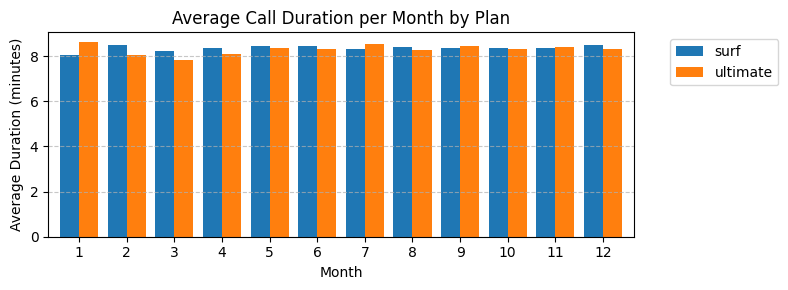

In [42]:
#31.2 Compare a duração média das chamadas de cada plano para cada mês. Crie um gráfico de barras para visualizar o resultado.

# preparando para criar o gráfico

calls_pivot_stats = average_calls_per_plan.pivot(index='month', columns='plan', values='average_call')

# the grouped bar chart
ax = calls_pivot_stats.plot(kind='bar', figsize=(8, 3), width=0.8)

# labels and title

plt.title('Average Call Duration per Month by Plan')
plt.xlabel('Month')
plt.ylabel('Average Duration (minutes)')
plt.xticks(rotation=0)
plt.legend(title='Plan')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


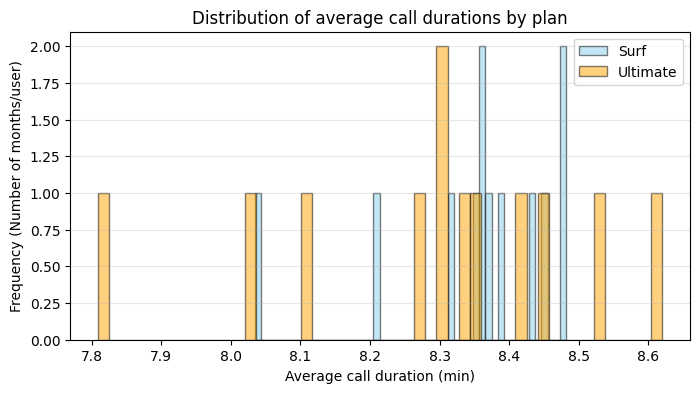

In [43]:
#32 Compare o número de minutos que os usuários de cada plano necessitam a cada mês. Construa um histograma.

surf_calls = average_calls_per_plan[average_calls_per_plan['plan'] == 'surf']['average_call']

ultimate_calls = average_calls_per_plan[average_calls_per_plan['plan'] == 'ultimate']['average_call']

plt.figure(figsize = (8, 4))

plt.hist(surf_calls, bins=50, alpha = 0.5, label = 'Surf', color = 'skyblue', edgecolor = 'black')

plt.hist(ultimate_calls, bins=50, alpha = 0.5, label = 'Ultimate', color = 'orange', edgecolor = 'black')

plt.title('Distribution of average call durations by plan')
plt.xlabel('Average call duration (min)')
plt.ylabel('Frequency (Number of months/user)')
plt.legend(loc = 'upper right')
plt.grid(axis = 'y', alpha = 0.3)

plt.show()


[Calcule a média e a variância da duração das chamadas para refletir se os usuários de cada plano possuem comportamentos diferentes sobre as chamadas.]

In [44]:
#33 Calcule a média e a variância da duração mensal das chamadas

calls_stats = average_calls_per_plan.groupby('plan')['average_call'].agg(['mean', 'var']).reset_index()

# Renaming columns
calls_stats.columns = ['plan', 'mean duration', 'variance']

display(calls_stats)



,plan,mean duration,variance
0,surf,8.352763,0.015477
1,ultimate,8.293291,0.049196


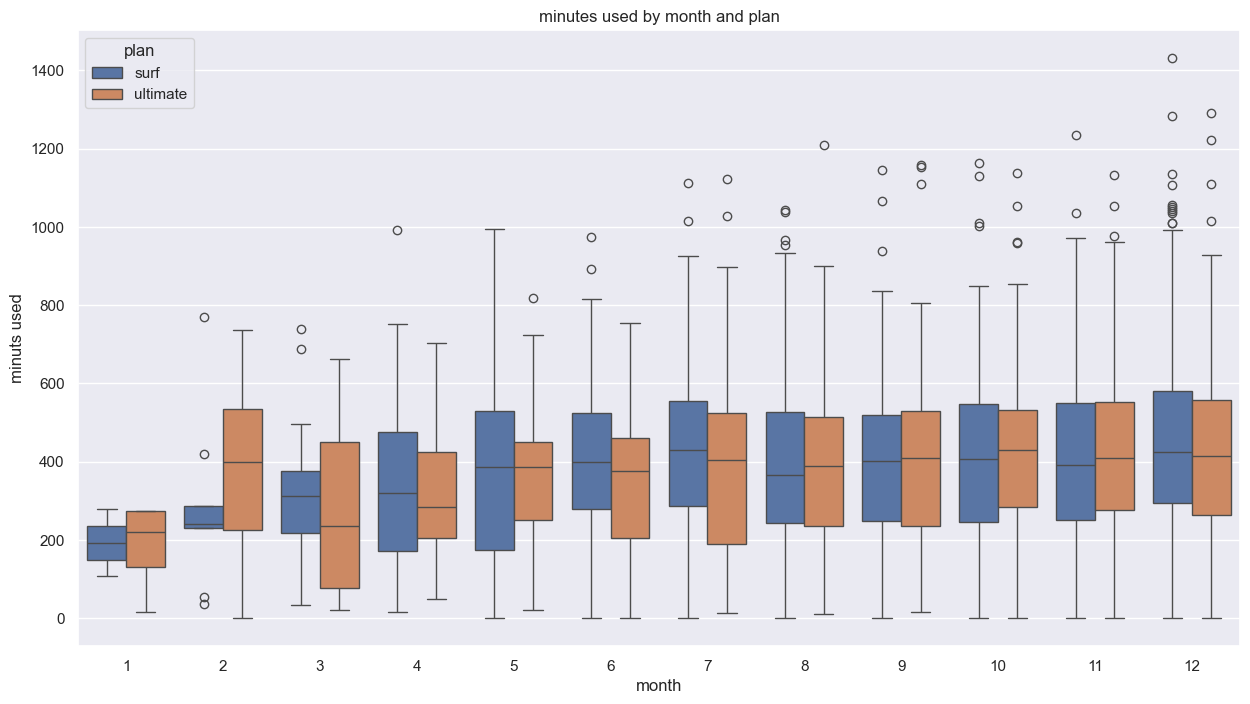

In [45]:
#34 Faça um diagrama de caixa para visualizar a distribuição da duração mensal das chamadas

# criando o boxplot

sns.set_theme(rc={'figure.figsize':(15, 8)})

sns.boxplot(data=users_plans, x='month', y='min_used', hue='plan')


#definindo os labels
plt.title('minutes used by month and plan')
plt.xlabel('month')
plt.ylabel('minuts used')

plt.show()



[Formule conclusões sobre como os usuários se comportam em termos de chamadas. O comportamento é diferente dependendo do plano?]

aparentemente são pouco perceptíveis as diferenças entre as variáveis estatísticas dos planos. Concluo, até aqui, que o comportamento dos usários não é diferente, apesar do plano.

### Mensagens

In [46]:
#35.1 criando um dataframe para comparar a quantidade de mensagens enviadas em cada plano

sms_per_plan = users_plans.groupby(['plan', 'month']).agg({'sms_used': 'sum'}).reset_index()


display(sms_per_plan.head(5))

,plan,month,sms_used
0,surf,1,21.0
1,surf,2,108.0
2,surf,3,351.0
3,surf,4,870.0
4,surf,5,1849.0


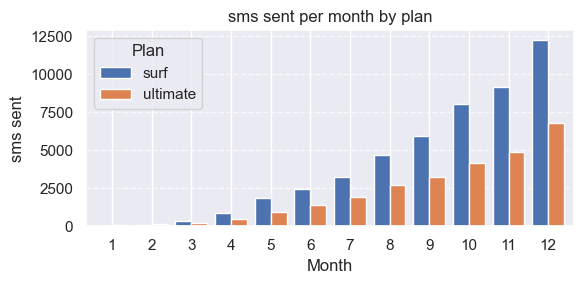

In [47]:
#35.2 Compare o número de mensagens que os usuários de cada plano costumam enviar a cada mês
# preparando para criar o gráfico

sms_pivot_stats = sms_per_plan.pivot(index='month', columns='plan', values='sms_used')

# the grouped bar chart
ax = sms_pivot_stats.plot(kind='bar', figsize=(6, 3), width=0.8)

# labels and title

plt.title('sms sent per month by plan')
plt.xlabel('Month')
plt.ylabel('sms sent')
plt.xticks(rotation=0)
plt.legend(title='Plan')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


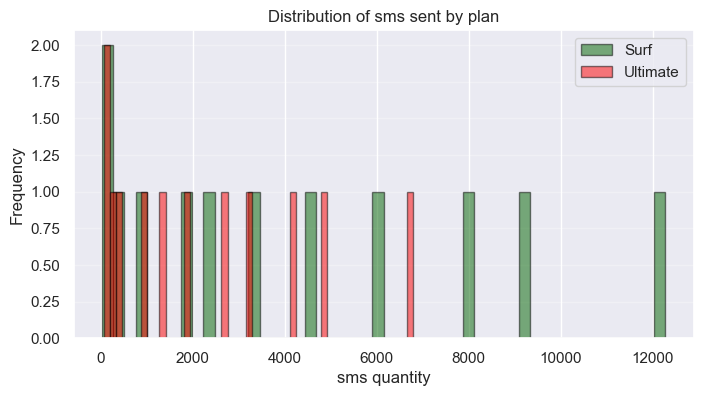

In [48]:
#35.3 histograma

surf_sms = sms_per_plan[sms_per_plan['plan'] == 'surf']['sms_used']

ultimate_sms = sms_per_plan[sms_per_plan['plan'] == 'ultimate']['sms_used']

plt.figure(figsize = (8, 4))

plt.hist(surf_sms, bins=50, alpha = 0.5, label = 'Surf', color = 'darkgreen', edgecolor = 'black')

plt.hist(ultimate_sms, bins=50, alpha = 0.5, label = 'Ultimate', color = 'red', edgecolor = 'black')

plt.title('Distribution of sms sent by plan')
plt.xlabel('sms quantity')
plt.ylabel('Frequency')
plt.legend(loc = 'upper right')
plt.grid(axis = 'y', alpha = 0.3)

plt.show()



In [49]:
#35.4 mean and variance

sms_stats = sms_per_plan.groupby('plan')['sms_used'].agg(['mean', 'var']).reset_index()

# Renaming columns
sms_stats.columns = ['plan', 'mean quantity', 'variance']

display(sms_stats)


,plan,mean quantity,variance
0,surf,4084.500000,1.610722e+07
1,ultimate,2253.083333,4.699501e+06


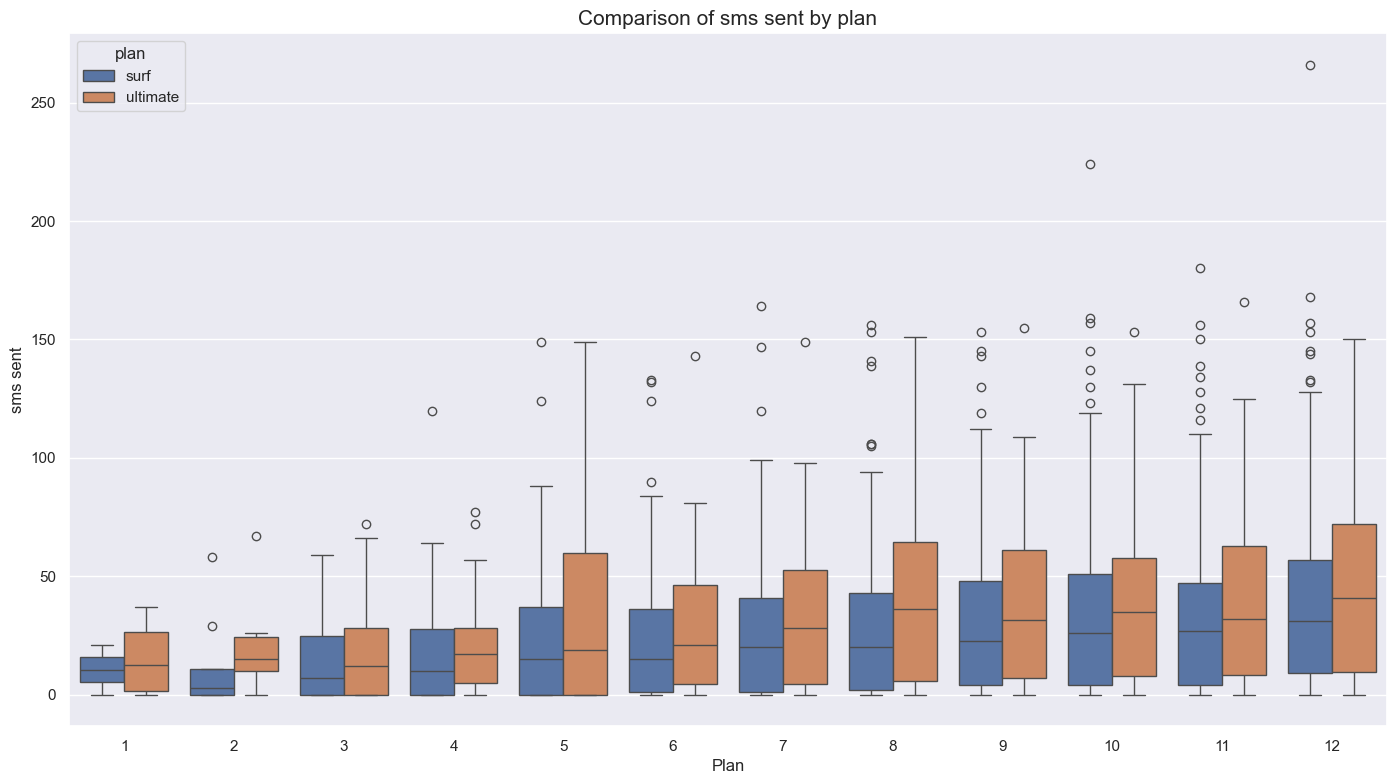

In [50]:
#35.5
# criando o boxplot

sns.set_theme(rc={'figure.figsize':(17, 9)})

sns.boxplot(data = users_plans, x='month', y='sms_used', hue='plan')

#titles and labels
plt.title('Comparison of sms sent by plan', fontsize=15)
plt.xlabel('Plan', fontsize=12)
plt.ylabel('sms sent', fontsize=12)

plt.show()


### Internet

In [51]:
#36 Compare a quantidade de tráfego de internet consumido pelos usuários por plano

In [52]:
#36.1 criando um dataframe para comparar.

internet_consumed_per_plan = users_plans.groupby(['plan', 'month']).agg({'gb_used': 'sum'}).reset_index()

display(internet_consumed_per_plan.head(3))


,plan,month,gb_used
0,surf,1,10.0
1,surf,2,110.0
2,surf,3,311.0


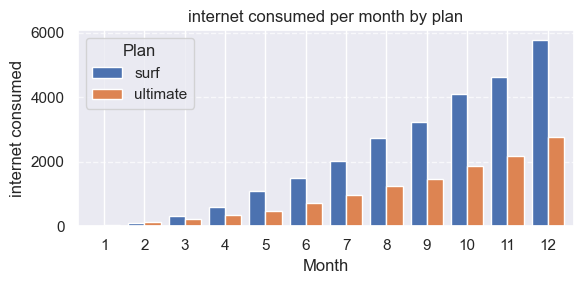

In [53]:
#37
# preparando para criar o gráfico

internet_pivot_stats = internet_consumed_per_plan.pivot(index='month', columns='plan', values='gb_used')

# the grouped bar chart
ax = internet_pivot_stats.plot(kind='bar', figsize=(6, 3), width=0.8)

# labels and title

plt.title('internet consumed per month by plan')
plt.xlabel('Month')
plt.ylabel('internet consumed')
plt.xticks(rotation=0)
plt.legend(title='Plan')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


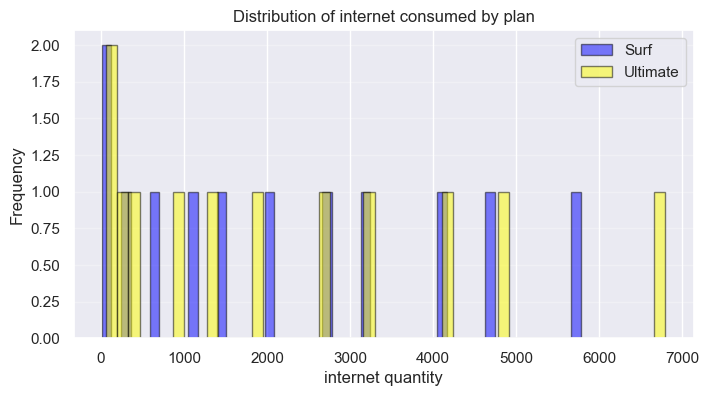

In [54]:
#38 Histograma

surf_internet = internet_consumed_per_plan[internet_consumed_per_plan['plan'] == 'surf']['gb_used']

ultimate_internet = internet_consumed_per_plan[internet_consumed_per_plan['plan'] == 'ultimate']['gb_used']

plt.figure(figsize = (8, 4))

plt.hist(surf_internet, bins=50, alpha = 0.5, label = 'Surf', color = 'blue', edgecolor = 'black')

plt.hist(ultimate_sms, bins=50, alpha = 0.5, label = 'Ultimate', color = 'yellow', edgecolor = 'black')

plt.title('Distribution of internet consumed by plan')
plt.xlabel('internet quantity')
plt.ylabel('Frequency')
plt.legend(loc = 'upper right')
plt.grid(axis = 'y', alpha = 0.3)

plt.show()


In [55]:
#39 mean and variance

internet_stats = internet_consumed_per_plan.groupby('plan')['gb_used'].agg(['mean', 'var']).reset_index()

# Renaming columns
internet_stats.columns = ['plan', 'mean quantity', 'variance']

display(internet_stats)


,plan,mean quantity,variance
0,surf,2178.000000,3.702590e+06
1,ultimate,1035.166667,7.835663e+05


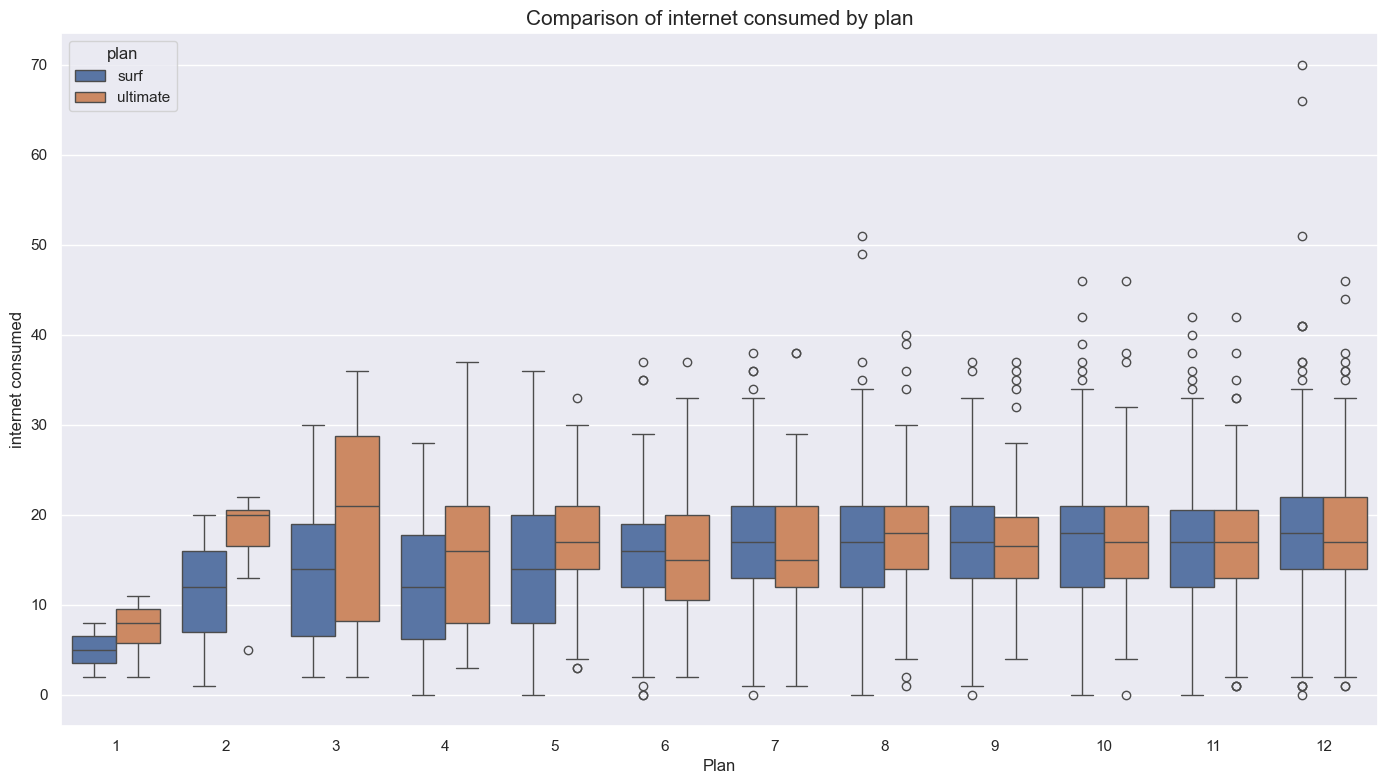

In [56]:
#40 criando o boxplot

sns.set_theme(rc={'figure.figsize':(17, 9)})

sns.boxplot(data = users_plans, x='month', y='gb_used', hue='plan')


# Add titles and labels
plt.title('Comparison of internet consumed by plan', fontsize=15)
plt.xlabel('Plan', fontsize=12)
plt.ylabel('internet consumed', fontsize=12)

plt.show()


[Formule conclusões sobre como os usuários tendem a consumir o tráfego da internet. O comportamento é diferente dependendo do plano?]

O consumo de internet é similar entre os planos.

## Receita

[Da mesma forma que você estudou o comportamento dos usuários, descreva estatisticamente as receitas dos planos.]

In [57]:
display(users_plans.head(3))

,user_id,month,calls_used,min_used,sms_used,gb_used,plan,plan_sms,plan_min,plan_price,$_gb,$_sms,$_min,plan_gb,extra_min_us$,extra_sms_us$,extra_gb_us$,total
0,1000,12,16.0,116.83,11.0,2.0,ultimate,1000,3000,70.0,7.0,0.01,0.01,30,0.0,0.0,0.0,70.0
1,1001,8,22.0,171.14,30.0,7.0,surf,50,500,20.0,10.0,0.03,0.03,15,0.0,0.0,0.0,20.0
2,1001,9,38.0,297.69,44.0,13.0,surf,50,500,20.0,10.0,0.03,0.03,15,0.0,0.0,0.0,20.0


In [58]:
#41
revenue_per_plan = users_plans.groupby(['plan', 'month']).agg({'total': 'sum'}).reset_index()

display(revenue_per_plan.head(3))


,plan,month,total
0,surf,1,40.0
1,surf,2,310.0
2,surf,3,1056.0


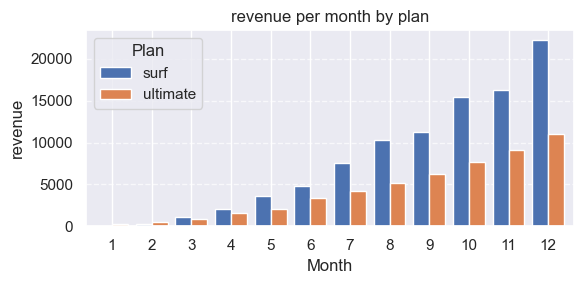

In [59]:
#42

# preparando para criar o gráfico

revenue_pivot_stats = revenue_per_plan.pivot(index='month', columns='plan', values='total')

# the grouped bar chart
ax = revenue_pivot_stats.plot(kind='bar', figsize=(6, 3), width=0.8)

# labels and title

plt.title('revenue per month by plan')
plt.xlabel('Month')
plt.ylabel('revenue')
plt.xticks(rotation=0)
plt.legend(title='Plan')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()



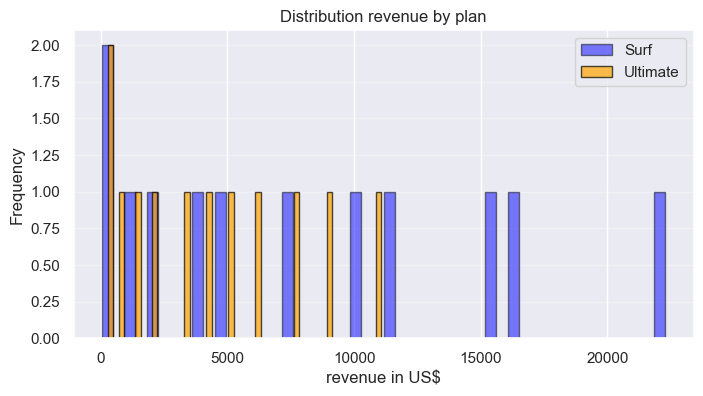

In [60]:
#43 Histograma

surf_revenue = revenue_per_plan[revenue_per_plan['plan'] == 'surf']['total']

ultimate_revenue = revenue_per_plan[revenue_per_plan['plan'] == 'ultimate']['total']

plt.figure(figsize = (8, 4))

plt.hist(surf_revenue, bins=50, alpha = 0.5, label = 'Surf', color = 'blue', edgecolor = 'black')

plt.hist(ultimate_revenue, bins=50, alpha = 0.7, label = 'Ultimate', color = 'orange', edgecolor = 'black')

plt.title('Distribution revenue by plan')
plt.xlabel('revenue in US$')
plt.ylabel('Frequency')
plt.legend(loc = 'upper right')
plt.grid(axis = 'y', alpha = 0.3)

plt.show()


In [61]:
#44 Mean and variance

revenue_stats = revenue_per_plan.groupby('plan')['total'].agg(['mean', 'var']).reset_index()

# Renaming columns
revenue_stats.columns = ['plan', 'mean revenue', 'variance']

display(revenue_stats)


,plan,mean revenue,variance
0,surf,7903.916667,5.267552e+07
1,ultimate,4337.666667,1.276340e+07


In [62]:
display(users_plans.head(1))


,user_id,month,calls_used,min_used,sms_used,gb_used,plan,plan_sms,plan_min,plan_price,$_gb,$_sms,$_min,plan_gb,extra_min_us$,extra_sms_us$,extra_gb_us$,total
0,1000,12,16.0,116.83,11.0,2.0,ultimate,1000,3000,70.0,7.0,0.01,0.01,30,0.0,0.0,0.0,70.0


Duas opções: o gráfico n me parece incorreto. Apenas achata um dos planos
Tenta colocar o parâmetro no sns.boxplot de dodge=True,
 ou hue_order=['ultimate', 'surf'] -inverte a ordem do hue
Última opção é separar os planos cada um em um subplot

In [63]:

ultimate_plan = users_plans[users_plans['plan'] == 'ultimate']
display(ultimate_plan.sample(30))


,user_id,month,calls_used,min_used,sms_used,gb_used,plan,plan_sms,plan_min,plan_price,$_gb,$_sms,$_min,plan_gb,extra_min_us$,extra_sms_us$,extra_gb_us$,total
1025,1214,7,48.0,444.37,24.0,17.0,ultimate,1000,3000,70.0,7.0,0.01,0.01,30,0.0,0.0,0.0,70.0
680,1144,4,19.0,152.09,21.0,8.0,ultimate,1000,3000,70.0,7.0,0.01,0.01,30,0.0,0.0,0.0,70.0
1090,1231,10,67.0,510.45,3.0,17.0,ultimate,1000,3000,70.0,7.0,0.01,0.01,30,0.0,0.0,0.0,70.0
1808,1390,4,44.0,342.56,0.0,14.0,ultimate,1000,3000,70.0,7.0,0.01,0.01,30,0.0,0.0,0.0,70.0
414,1085,12,72.0,552.14,0.0,25.0,ultimate,1000,3000,70.0,7.0,0.01,0.01,30,0.0,0.0,0.0,70.0
1776,1384,7,27.0,202.24,98.0,25.0,ultimate,1000,3000,70.0,7.0,0.01,0.01,30,0.0,0.0,0.0,70.0
2104,1456,10,37.0,285.35,27.0,8.0,ultimate,1000,3000,70.0,7.0,0.01,0.01,30,0.0,0.0,0.0,70.0
1592,1346,5,27.0,233.72,53.0,18.0,ultimate,1000,3000,70.0,7.0,0.01,0.01,30,0.0,0.0,0.0,70.0
138,1039,6,36.0,305.21,4.0,6.0,ultimate,1000,3000,70.0,7.0,0.01,0.01,30,0.0,0.0,0.0,70.0
130,1036,9,39.0,276.65,83.0,15.0,ultimate,1000,3000,70.0,7.0,0.01,0.01,30,0.0,0.0,0.0,70.0


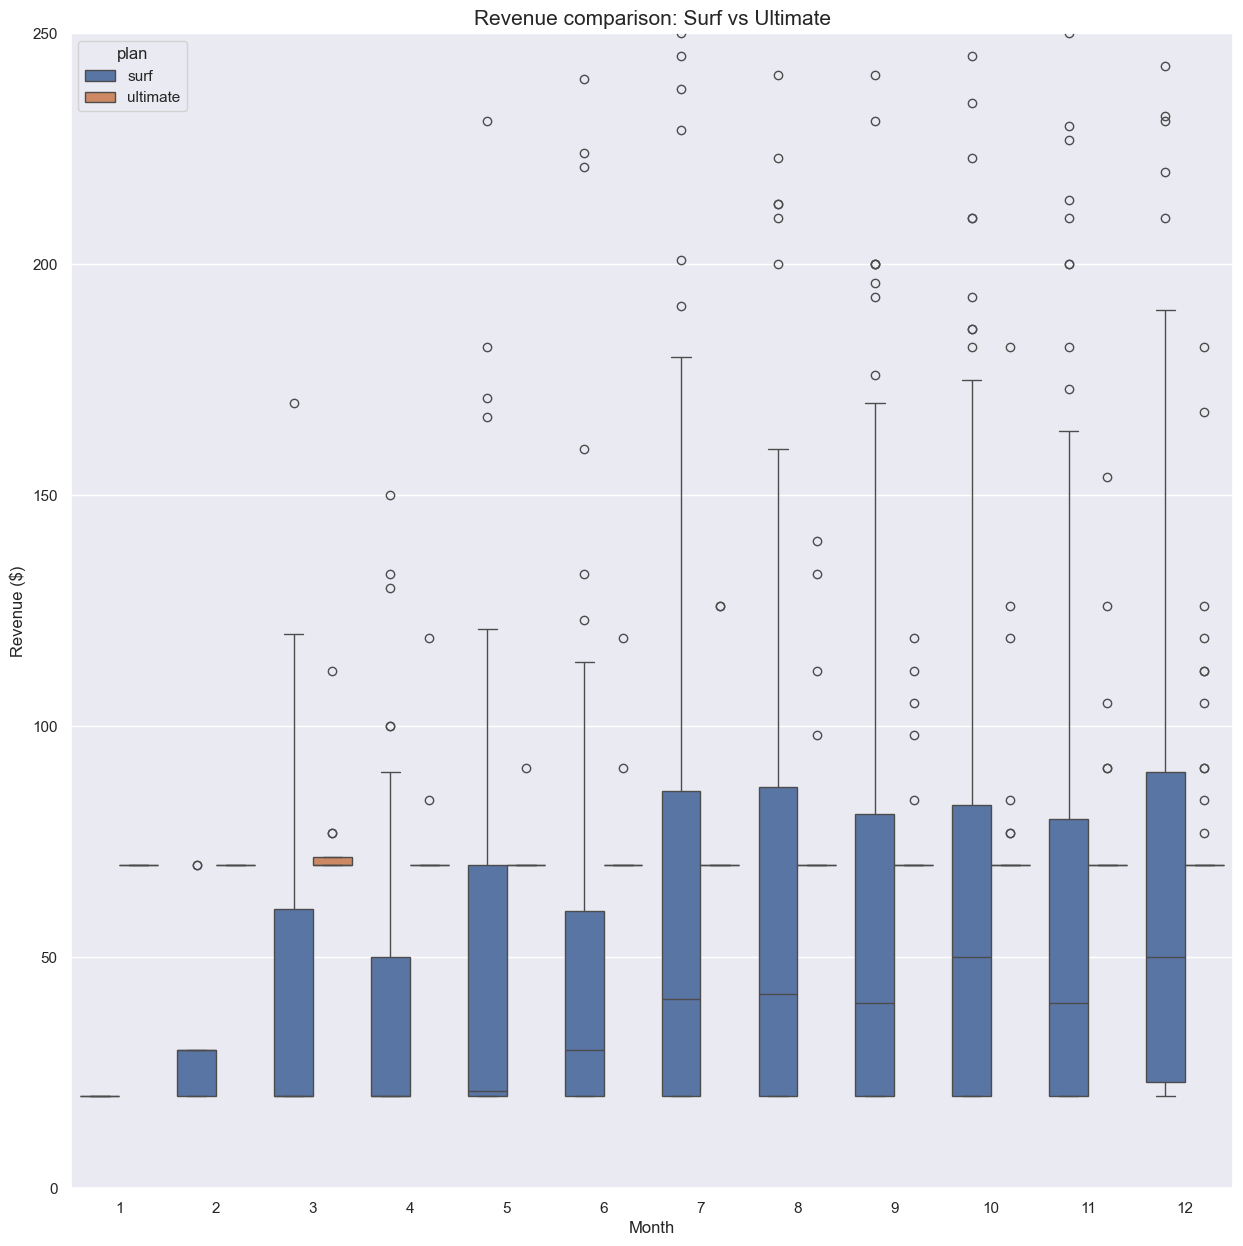

In [74]:
#45 boxplot 

plt.figure(figsize=(15, 15))
sns.boxplot(data=users_plans, x='month', y='total', hue='plan', dodge=True)
plt.ylim(0, 250)  # corta outliers extremos pra ver melhor as caixas
plt.title('Revenue comparison: Surf vs Ultimate', fontsize=15)
plt.xlabel('Month', fontsize=12)

plt.ylabel('Revenue ($)', fontsize=12)
plt.show()


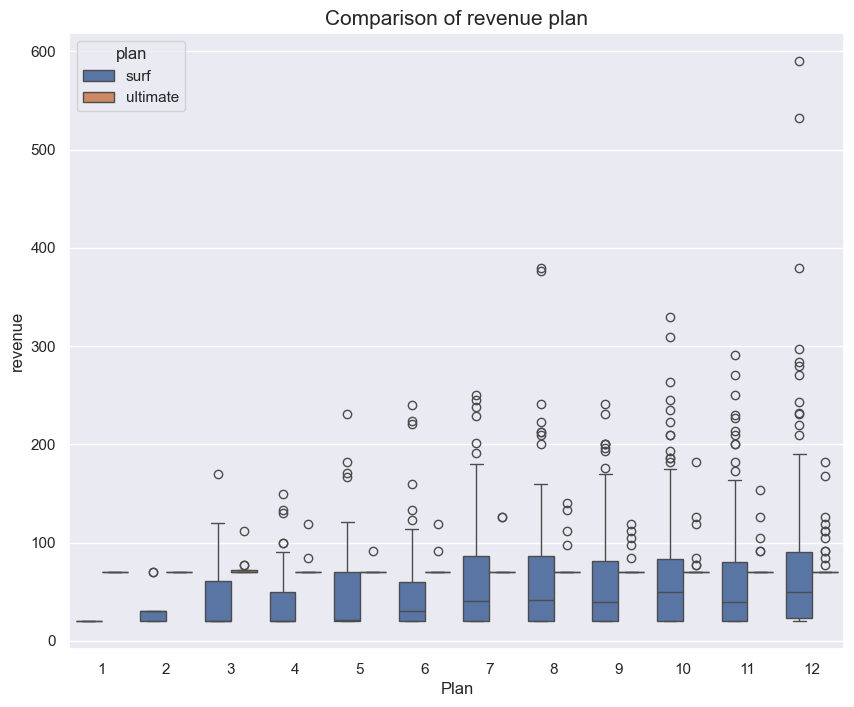

In [76]:
#45 boxplot

sns.set_theme(rc={'figure.figsize':(10, 8)})

sns.boxplot(data = users_plans, x = 'month', y = 'total', hue = 'plan', dodge = True)

# Add titles and labels
plt.title('Comparison of revenue plan', fontsize=15)
plt.xlabel('Plan', fontsize=12)
plt.ylabel('revenue', fontsize=12)

plt.show()


[Formule conclusões sobre como a receita difere entre os planos.]

In [66]:
extra_gb_revenue = users_plans.groupby('plan').agg({'extra_gb_us$':'sum'})

print('Como podemos observar na tabela abaixo, o plano surf gera uma receita extra, devido à necessidade que os clientes têm de consumir mais internet do que é oferecido no plano.\n')

print(extra_gb_revenue)


Como podemos observar na tabela abaixo, o plano surf gera uma receita extra, devido à necessidade que os clientes têm de consumir mais internet do que é oferecido no plano.

          extra_gb_us$
plan                  
surf           60300.0
ultimate        1652.0


## Teste hipóteses estatísticas

[Teste a hipótese de que a receita média dos usuários dos planos Ultimate e Surf são diferentes.]

[Formule as hipóteses nula e alternativa, escolha o teste estatístico, escolha o valor alfa.]

In [67]:
display(revenue_stats)

,plan,mean revenue,variance
0,surf,7903.916667,5.267552e+07
1,ultimate,4337.666667,1.276340e+07


In [68]:
display(users_plans.head(3))


,user_id,month,calls_used,min_used,sms_used,gb_used,plan,plan_sms,plan_min,plan_price,$_gb,$_sms,$_min,plan_gb,extra_min_us$,extra_sms_us$,extra_gb_us$,total
0,1000,12,16.0,116.83,11.0,2.0,ultimate,1000,3000,70.0,7.0,0.01,0.01,30,0.0,0.0,0.0,70.0
1,1001,8,22.0,171.14,30.0,7.0,surf,50,500,20.0,10.0,0.03,0.03,15,0.0,0.0,0.0,20.0
2,1001,9,38.0,297.69,44.0,13.0,surf,50,500,20.0,10.0,0.03,0.03,15,0.0,0.0,0.0,20.0


In [69]:
#47 Teste as hipóteses

H0 =  ('as receitas médias são idênticas')
H1 = ('as receitas médias são diferentes')
alpha = 0.05

surf_revenue_stats = users_plans[users_plans['plan'] == 'surf']['total']
ultimate_revenue_stats = users_plans[users_plans['plan'] == 'ultimate']['total']

results = st.ttest_ind(surf_revenue_stats, ultimate_revenue_stats, equal_var = False)

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('\nRejeitamos a hipótese nula H0. As receitas médias são estatisticamente diferentes')
else:
    print('\nNão podemos rejeitar a hipótese nula; As receitas médias são estatisticamente iguais.')
    


p-value: 2.8132196600344744e-16

Rejeitamos a hipótese nula H0. As receitas médias são estatisticamente diferentes


[Teste a hipótese de que a receita média dos usuários da área de NY-NJ difere dos usuários das demais regiões.]

In [70]:
#48 criando um novo DataFrame que contenha o nome das cidades e o total
merged_df_users_plans = pd.merge(users_plans, df_users, on = ['user_id', 'plan'])

# removendo columnas desnecessárias
to_remove = ['calls_used', 'min_used', 'sms_used', 'gb_used', 'plan_sms', 'plan_min', 'plan_price', '$_gb', '$_sms', '$_min', 'plan_gb', 'extra_min_us$', 'extra_sms_us$', 'extra_gb_us$', 'first_name', 'last_name', 'age', 'reg_date', 'churn_date', 'tenure']

merged_df_users_plans = merged_df_users_plans.drop(columns = to_remove)

print(merged_df_users_plans.head(3))


   user_id  month      plan  total                                   city
0     1000     12  ultimate   70.0  Atlanta-Sandy Springs-Roswell, GA MSA
1     1001      8      surf   20.0        Seattle-Tacoma-Bellevue, WA MSA
2     1001      9      surf   20.0        Seattle-Tacoma-Bellevue, WA MSA


In [71]:
#49 criando uma máscara para filtrar meu dataframe
mask = merged_df_users_plans['city'].str.contains('NY | NJ', case = False, na = False) 

ny_nj_revenue = merged_df_users_plans[mask].copy()

other_cities = merged_df_users_plans[~mask].copy()



In [72]:

# 50
alpha = 0.05 

#preparando as colunas (Series) para serem testadas
ny_nj_revenue_stats = ny_nj_revenue['total']

other_cities_revenue_stats = other_cities['total']

# o teste em si
results = st.ttest_ind(ny_nj_revenue_stats, other_cities_revenue_stats, equal_var=False)

print('p-value:', results.pvalue)


if results.pvalue < alpha:
    print('\nRejeitamos a hipótese nula H0. As receitas médias são estatisticamente diferentes')
else:
    print('\nNão podemos rejeitar a hipótese nula; As receitas médias de NY-NJ vs demais cidades são estatisticamente iguais.')


p-value: 0.3767165450112354

Não podemos rejeitar a hipótese nula; As receitas médias de NY-NJ vs demais cidades são estatisticamente iguais.


In [73]:
print(f"NY-NJ mean revenue: {ny_nj_revenue_stats.mean():.2f}")
print(f"other cities mean revenue: {other_cities_revenue_stats.mean():.2f}")


NY-NJ mean revenue: 73.48
other cities mean revenue: 63.94


## Conclusão geral

[Liste suas conclusões importantes nesta seção final, certifique-se de que elas cobrem todas as decisões (suposições) importantes que você tomou e que levaram à maneira como você processou e analisou os dados.]

O plano surf é o que gera mais receita para a empresa.
Se a empresa estiver interessada em diminuir os gastos dos clientes (raciocínio contrário), ela deve fazer campanhas direcionadas para orientar os clientes surf das vantages do plano ultimate.